# 🔬 02 — Time Series Diagnostics
## Hormuz Strait Shipping Disruption — Daily Ship Transits

This notebook performs rigorous statistical diagnostics on `daily_ship_transits` to inform model selection in notebook 03. Given the severe structural break identified in EDA, special attention is paid to stationarity, structural breaks, and change points — not just standard ADF/ACF checks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

data = pd.read_csv('../data/raw/strait_of_hormuz_shipping_disruption_2026.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date').reset_index(drop=True)

target_col = 'daily_ship_transits'
ts = data.set_index('date')[target_col]
ts.head()

date
2026-01-01    103
2026-01-02    108
2026-01-03    108
2026-01-04    108
2026-01-05     98
Name: daily_ship_transits, dtype: int64

## 1. Stationarity Analysis

A stationary series has constant mean, variance, and autocorrelation structure over time. Most classical forecasting models (ARIMA) assume stationary. Given the level shift observed in EDA, we expect this series to be non-stationary.

## 2. Augmented Dickey-Fuller (ADF) Test

**Hypothese:**
- H0: The series has a unit root (non-stationary).
- H1: The series is stationary.

If p-value < 0.05, reject H0 -> series is stationary.

In [3]:
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {name} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    for key, val in result[4].items():
        print(f'Critical Value ({key}) : {val:.4f}')
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-Stationary'
    print(f'Conclustion    : {conclusion}\n')
    return result[1]

adf_p_level = adf_test(ts, 'Original Series (Level)')

--- ADF Test: Original Series (Level) ---
ADF Statistic : -1.2144
p-value       : 0.6674
Critical Value (1%) : -3.4847
Critical Value (5%) : -2.8853
Critical Value (10%) : -2.5795
Conclustion    : Non-Stationary



## 3. KPSS Test

KPSS complements ADF with oppsite hypothese:
- H0: The series IS stationary (around a level/trend)
- H1: The series is non_stationary

If p-value < 0.05, reject H0 -> series is non-stationary.

Using both ADF and KPSS together avoids relying on a single test, since they have different null hypothese and power characteristics.


In [4]:
def kpss_test(series, name=''):
    statistic, p_value, n_lags, crit_value = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'--- KPSS Test: {name} ---')
    print(f'KPSS Statistics: {statistic:.4f}')
    print(f'p_value        : {p_value:.4f}')
    
    for key, val in crit_value.items():
        print(f'Critical Value ({key}): {val:.4f}')
    conclusion = 'Non-Stationary' if p_value < 0.05 else 'Stationary'
    print(f'Conclusion      : {conclusion}\n')
    return p_value

kpss_p_level = kpss_test(ts, 'Original Series (Level)')

--- KPSS Test: Original Series (Level) ---
KPSS Statistics: 1.5556
p_value        : 0.0100
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390
Conclusion      : Non-Stationary



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23832\5075613.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic, p_value, n_lags, crit_value = kpss(series.dropna(), regression='c', nlags='auto')


**Interpretation:** If ADF says non-stationary (high p_value) and KPSS also says non-stationary (low p_value), both tests argee the series requires differencing - consistent with the strong level shift seen in EDA. If the two tests disagree, this itself is informative: it often signal a structure break (trend-stationary within regimes but not globally), which neither test handle well on its own.

## 4. Differencing

Apply first-order differencing and re-test stationarity on the differenced series.

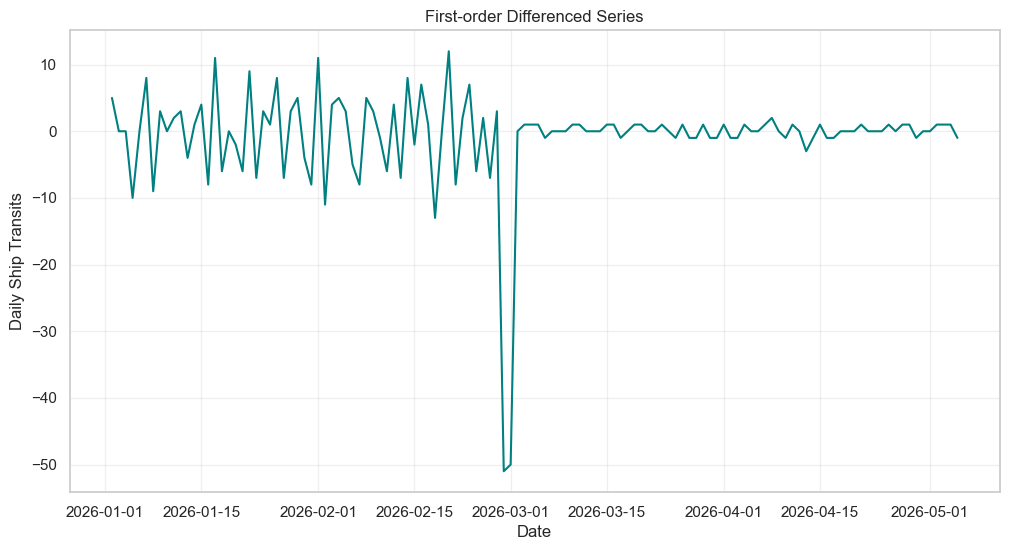

--- ADF Test: First Difference ---
ADF Statistic : -9.1573
p-value       : 0.0000
Critical Value (1%) : -3.4847
Critical Value (5%) : -2.8853
Critical Value (10%) : -2.5795
Conclustion    : Stationary

--- KPSS Test: First Difference ---
KPSS Statistics: 0.0946
p_value        : 0.1000
Critical Value (10%): 0.3470
Critical Value (5%): 0.4630
Critical Value (2.5%): 0.5740
Critical Value (1%): 0.7390
Conclusion      : Stationary



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23832\5075613.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, crit_value = kpss(series.dropna(), regression='c', nlags='auto')


In [5]:
ts_diff1 = ts.diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(ts_diff1, color='teal')
plt.title('First-order Differenced Series')
plt.xlabel('Date')
plt.ylabel('Daily Ship Transits')
plt.grid(alpha=0.3)
plt.show()

adf_p_diff1 = adf_test(ts_diff1, 'First Difference')
kpss_p_diff1 = kpss_test(ts_diff1, 'First Difference')

**Interpretation:** First differencing should remove the level component. If both tests now agree on stationarity, `d=1` is an appropriate differencing order for ARIMA. Note however that differencing addresses gradual trends well but converts a one-time level shift into a single large spike in the differenced series — visible as the sharp spike around the regime-change date above. This spike is a structural artifact, not noise.

## 5. ACF (Autocorrelation Function) Analysis

The ACF show correlation between the series and its lagged values, including indirect effects through intermediate lags. Used to identify the MA(q) order.

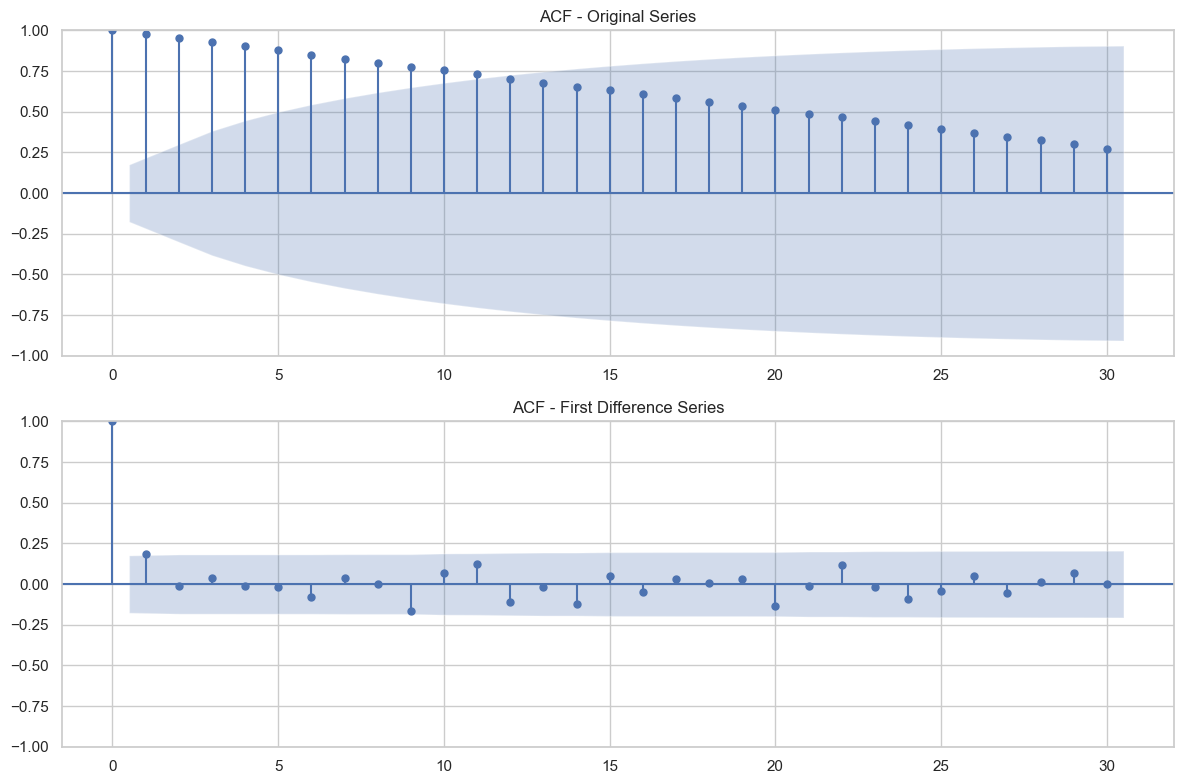

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(ts, lags=30, ax=axes[0])
axes[0].set_title('ACF - Original Series')
plot_acf(ts_diff1, lags=30, ax=axes[1])
axes[1].set_title('ACF - First Difference Series')
plt.tight_layout()
plt.show()

## 6. PACF Analysis

The PACF shows the direct correlation between the series and a specific lag, removing the effect of intermediate lags. Used to identify the AR(p) order.

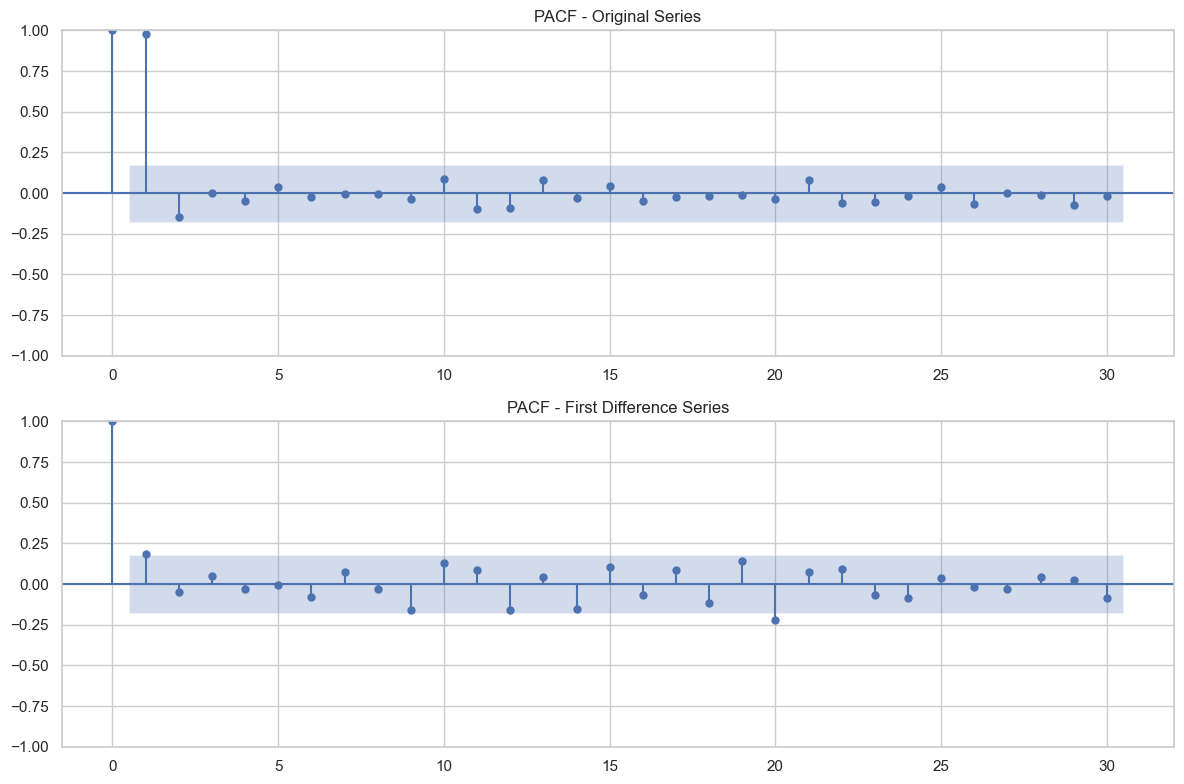

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12,8))
plot_pacf(ts, lags=30, ax=axes[0], method='ywm')
axes[0].set_title('PACF - Original Series')
plot_pacf(ts_diff1, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF - First Difference Series')
plt.tight_layout()
plt.show()

**Interpretation:** On the original series, ACF decays very slowly — a classic signature of non-stationarity (and here, of the level shift). On the differenced series, look for the lag at which ACF/PACF cut off or decay sharply to suggest candidate (p, q) values for notebook 03. Be cautious: with only 125 observations and one dominant structural break, ACF/PACF patterns may be dominated by that single event rather than reflecting genuine short-term dependence.

## 7. Seasonal Decomposition

Decompose the series into trend, seasonal, and residual components using a weekly (7-day) period, the natural candidate given daily shipping operations.

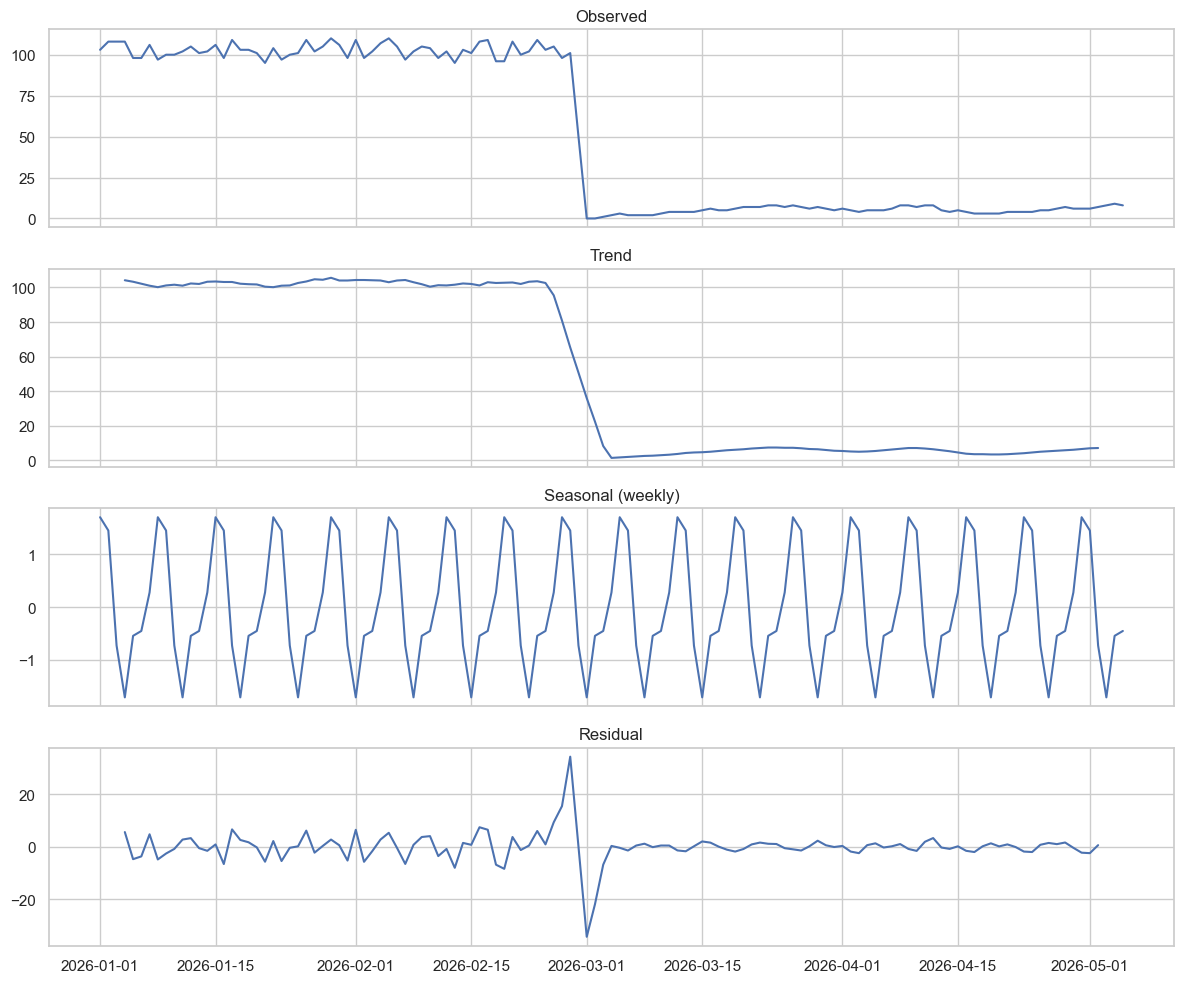

In [8]:
decomposition = seasonal_decompose(ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(decomposition.observed); axes[0].set_title('Observed')
axes[1].plot(decomposition.trend); axes[1].set_title('Trend')
axes[2].plot(decomposition.seasonal); axes[2].set_title('Seasonal (weekly)')
axes[3].plot(decomposition.resid); axes[3].set_title('Residual')
plt.tight_layout()
plt.show()

## 8. Trend Decomposition (STL — Robust)

STL (Seasonal-Trend decomposition using LOESS) with `robust=True` is more resilient to the extreme outliers/level shift than classical additive decomposition, giving a cleaner view of the underlying trend shape.

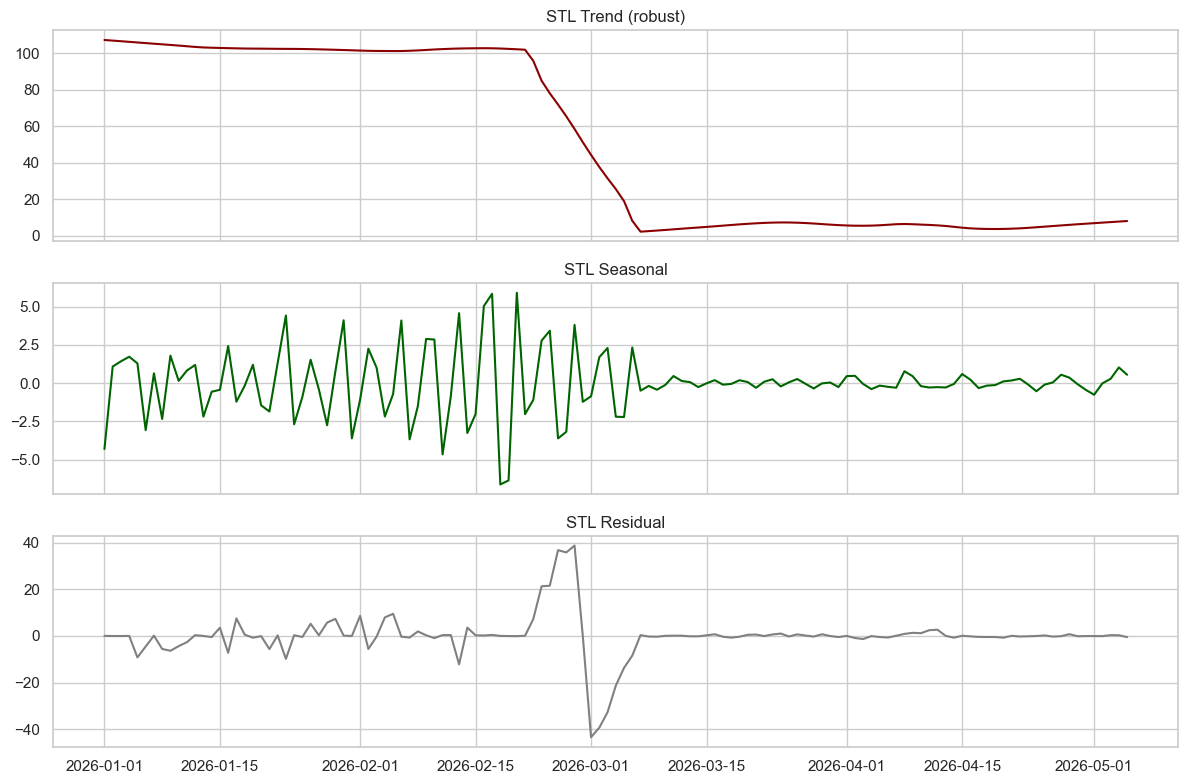

In [9]:
stl = STL(ts, period=7, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(stl_result.trend, color='darkred'); axes[0].set_title('STL Trend (robust)')
axes[1].plot(stl_result.seasonal, color='darkgreen'); axes[1].set_title('STL Seasonal')
axes[2].plot(stl_result.resid, color='gray'); axes[2].set_title('STL Residual')
plt.tight_layout()
plt.show()

**Interpretation:** Both decompositions should show a trend component that resembles a step function rather than a smooth slope — confirming the "trend" here is really a one-time regime shift. The seasonal component's amplitude should be checked: if it is small relative to the trend's range, weekly seasonality is not a major driver of this series.


## 9. Structural Break Detection

Use the `ruptures` library (PELT algorithm) to statistically detect break points in the mean of the series, and compare against the known `period_type` transition.

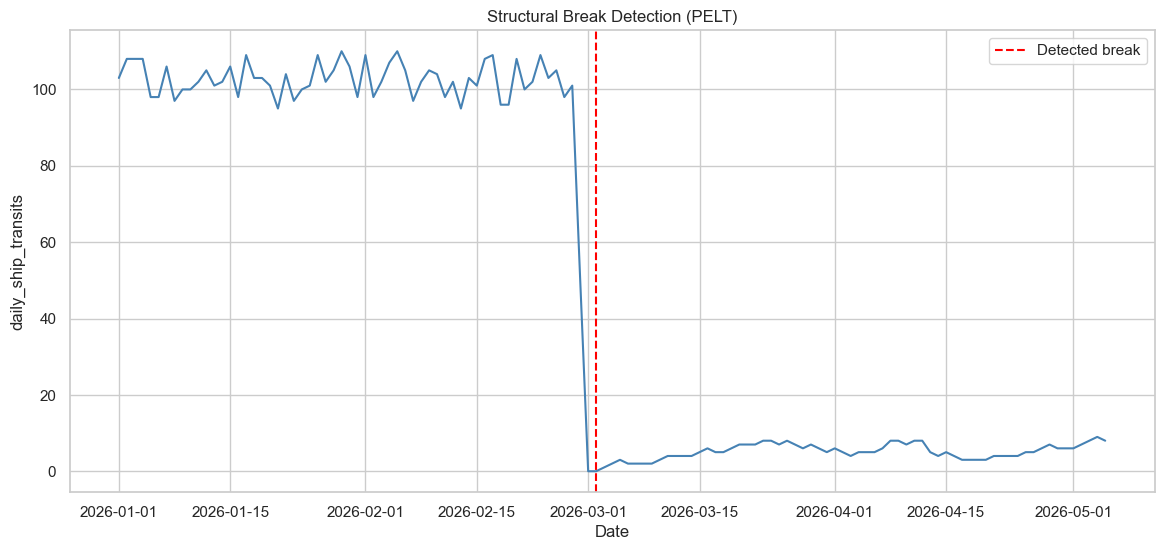

Detected break date(s): [Timestamp('2026-03-02 00:00:00')]
Known period_type transition date: 2026-02-28


In [10]:
try:
    import ruptures as rpt
    HAS_RUPTURES = True
except ImportError:
    HAS_RUPTURES = False
    print("ruptures not installed. Install via: pip install ruptures --break-system-packages")

if HAS_RUPTURES:
    signal = ts.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=10)

    plt.figure(figsize=(14, 6))
    plt.plot(ts.index, signal, color='steelblue')
    for bp in breakpoints[:-1]:
        plt.axvline(ts.index[bp], color='red', linestyle='--', label='Detected break')
    plt.title('Structural Break Detection (PELT)')
    plt.xlabel('Date'); plt.ylabel(target_col)
    plt.legend()
    plt.show()

    detected_dates = [ts.index[b] for b in breakpoints[:-1]]
    print("Detected break date(s):", detected_dates)

    # Compare with known period_type transition
    transition_idx = data[data['period_type'] == 'war_crisis'].index.min()
    transition_date = data.loc[transition_idx, 'date']
    print("Known period_type transition date:", transition_date.date())

**Interpretation:** If the algorithm-detected break date closely matches the `period_type` transition date, this provides statistical confirmation (independent of the metadata label) that a genuine structural break exists at this point. This justifies splitting the modeling approach by regime or including a regime dummy variable as an exogenous SARIMAX feature in notebook 03.

## 10. Change Point Detection (Volatility)

Beyond mean shifts, detect changes in *volatitily* using a rolling standard deviation signal - relevant for confidence-interval witdth and risk-based application.

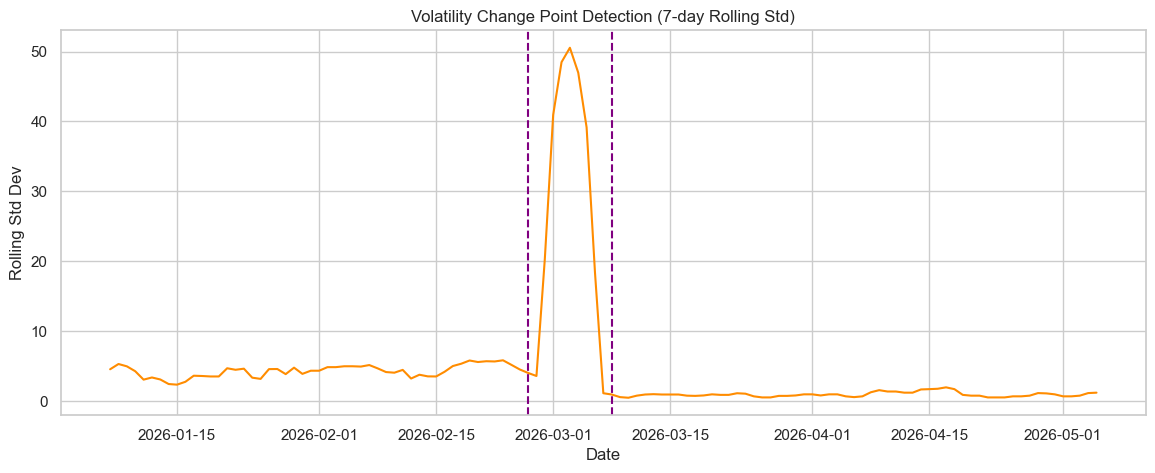

Detected volatility change date(s): [Timestamp('2026-02-26 00:00:00'), Timestamp('2026-03-08 00:00:00')]


In [11]:
rolling_std = ts.rolling(window=7).std().dropna()

if HAS_RUPTURES:
    algo_var = rpt.Pelt(model='rbf').fit(rolling_std.values)
    var_breaks = algo_var.predict(pen=3)

    plt.figure(figsize=(14, 5))
    plt.plot(rolling_std.index, rolling_std.values, color='darkorange')
    for bp in var_breaks[:-1]:
        plt.axvline(rolling_std.index[bp], color='purple', linestyle='--')
    plt.title('Volatility Change Point Detection (7-day Rolling Std)')
    plt.xlabel('Date'); plt.ylabel('Rolling Std Dev')
    plt.show()

    print("Detected volatility change date(s):", [rolling_std.index[b] for b in var_breaks[:-1]])

**Interpretation:** A volatility change point near (or slightly before) the mean-level break date indicates that uncertainty increased around the transition itself, not just after settling into the new regime — forecasts spanning this transition window should carry wider confidence intervals.

11. Lag Analysis (Cross-Correlation with Exogenous Variables)

Examine whether other variables in the dataset (security incidents) lead changes in `daily_ship_transits`, which would support their use as exogenous regressors.

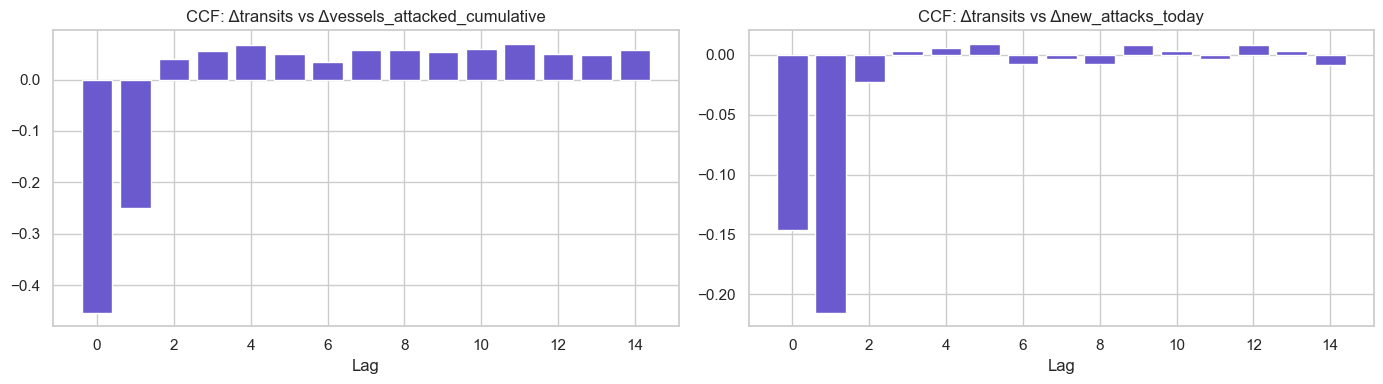

In [12]:
exog_candidates = ['vessels_attacked_cumulative', 'new_attacks_today']

fig, axes = plt.subplots(1, len(exog_candidates), figsize=(14, 4))
for ax, col in zip(axes, exog_candidates):
    target_diff = ts.diff().dropna()
    exog_diff = data.set_index('date')[col].diff().dropna()
    common_idx = target_diff.index.intersection(exog_diff.index)
    cc = ccf(target_diff.loc[common_idx], exog_diff.loc[common_idx])[:15]
    ax.bar(range(len(cc)), cc, color='slateblue')
    ax.set_title(f'CCF: Δtransits vs Δ{col}')
    ax.set_xlabel('Lag')
plt.tight_layout()
plt.show()


**Interpretation:** A notable cross-correlation at lag k>0 means changes in that variable tend to *precede* changes in transit volume by k days, making it a candidate leading-indicator feature for SARIMAX in notebook 03. Given only 125 observations and one dominant event, treat these correlations as exploratory signals rather than statistically robust relationships.


## 12. Correlation Analysis

Examine correlations between `daily_ship_transits` and other numeric variables in the dataset.

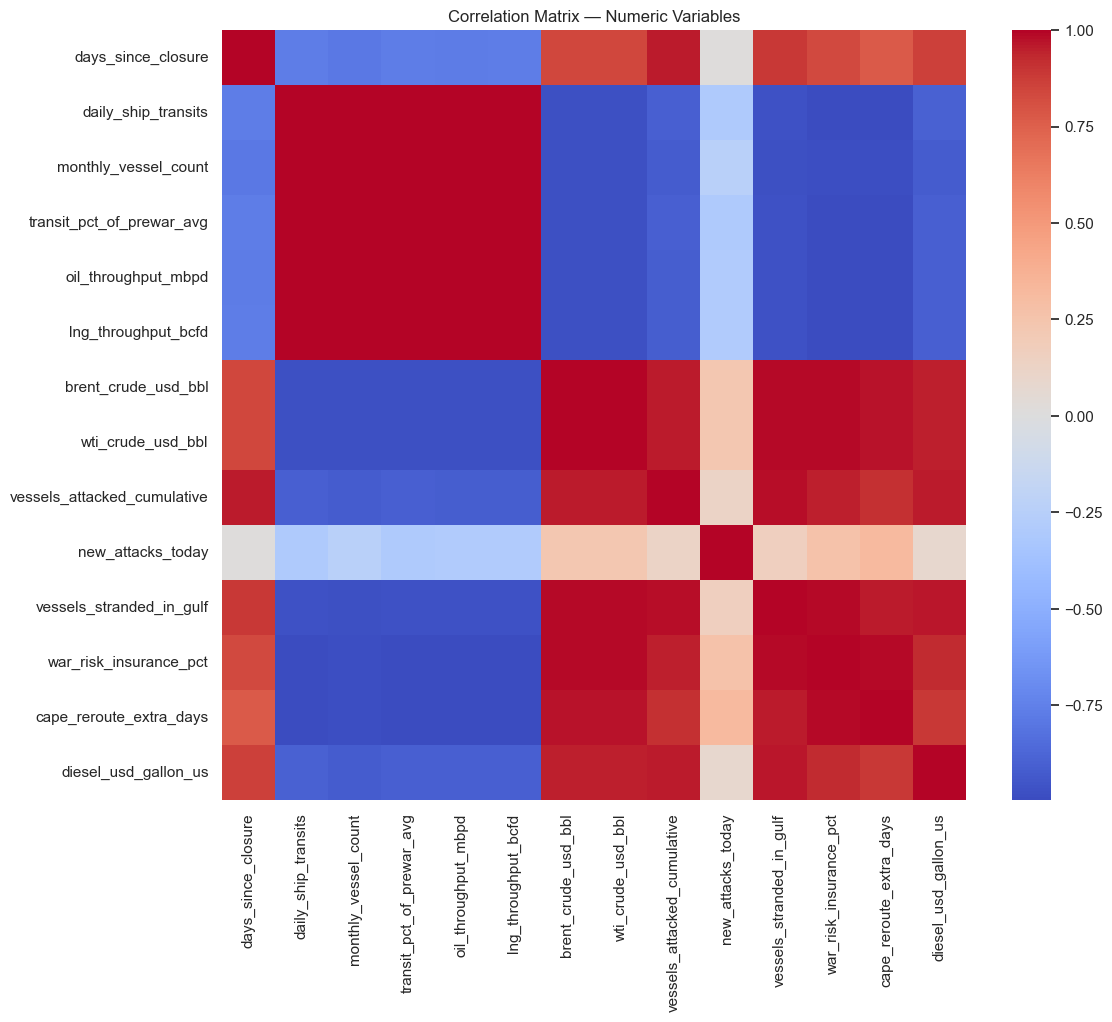

Top correlations with daily_ship_transits:
daily_ship_transits          1.000000
transit_pct_of_prewar_avg    0.998244
lng_throughput_bcfd          0.997901
oil_throughput_mbpd          0.997465
monthly_vessel_count         0.992694
new_attacks_today           -0.295767
days_since_closure          -0.765373
diesel_usd_gallon_us        -0.900943
Name: daily_ship_transits, dtype: float64
\nBottom correlations with daily_ship_transits:
cape_reroute_extra_days       -0.994383
war_risk_insurance_pct        -0.989310
brent_crude_usd_bbl           -0.975714
wti_crude_usd_bbl             -0.975358
vessels_stranded_in_gulf      -0.964813
vessels_attacked_cumulative   -0.908552
diesel_usd_gallon_us          -0.900943
days_since_closure            -0.765373
Name: daily_ship_transits, dtype: float64


In [13]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix — Numeric Variables')
plt.show()

print("Top correlations with daily_ship_transits:")
print(corr_matrix[target_col].sort_values(ascending=False).head(8))
print("\\nBottom correlations with daily_ship_transits:")
print(corr_matrix[target_col].sort_values().head(8))

**Interpretation:** Variables strongly (positively or negatively) correlated with the target — e.g., security incident counts, oil prices, days since closure — are strong candidates for exogenous features in SARIMAX. However, note that most of these correlations are driven by the same single regime shift (both variables jump at the same time), so high correlation here reflects shared structural break timing rather than necessarily a fine-grained causal relationship.

## 13. Time Series Diagnostics Summary

| Test | Result | Implication |
|---|---|---|
| ADF (level) | Non-stationary (p > 0.05) | Differencing required |
| KPSS (level) | Non-stationary (p < 0.05) | Confirms ADF result |
| ADF (1st diff) | Likely stationary | d = 1 appropriate |
| ACF (level) | Slow decay | Confirms non-stationarity / level shift |
| Seasonal decomposition | Small seasonal amplitude vs. trend range | Weekly seasonality is secondary |
| STL trend | Step-shaped, not smooth | Structural break dominates the series |
| Structural break (PELT) | ~1 major break detected | Aligns with `period_type` transition (war onset) |
| Volatility change point | Near the mean break | Transition window has highest uncertainty |
| Cross-correlation | Security incidents show lead relationship | Candidate exogenous regressor for SARIMAX |
| Correlation matrix | Multiple variables correlated via shared break | Use with caution; consider regime dummy |

### Recommendations for Notebook 03 (Modeling)
1. Use **d=1** as a starting point for ARIMA based on differencing results.
2. Include a **regime dummy variable** (`period_type` as 0/1) as an exogenous SARIMAX regressor to explicitly capture the structural break, rather than relying on differencing alone.
3. Consider **lagged security-incident counts** as additional exogenous features.
4. Given the small seasonal component, **weekly seasonal terms (SARIMA seasonal order) are optional/secondary** — test with and without.
5. Build a **naive/seasonal-naive baseline first** — given the series settles into a low, fairly flat regime post-crisis, naive forecasts may be surprisingly competitive.